# One-Site Association and Dissociation with Mass Transport Limitation

This notebook simulates one-site binding traces under mass transport limitation and plots association+dissociation traces together.

In [5]:
import numpy as np
from pykingenie.utils.signal_surface import (
    solve_ode_one_site_mass_transport_association,
    solve_ode_one_site_mass_transport_dissociation,
)
from pykingenie.utils.plotting import plot_traces
from pykingenie.utils.palettes import VIRIDIS
from notebook_helpers import show_plotly_static

## Parameters

- `Kd`: equilibrium dissociation constant (uM)
- `koff`: dissociation rate constant (1/s)
- `ktr`: mass transport rate constant (1/s)
- `smax`: maximum response

Ligand concentrations are log-spaced and traces use a Viridis palette.

In [9]:
Kd = 0.125
koff = 0.005
ktr = 0.02
smax = 5.0

concentrations = np.logspace(-2, 1, 6)
t_assoc = np.linspace(0, 300, 400)
t_disso = np.linspace(0, 300, 400)

colors = [VIRIDIS[int(i)] for i in np.linspace(0, len(VIRIDIS) - 1, len(concentrations))]

In [10]:
combined_xs, combined_ys, legends = [], [], []

for conc in concentrations:
    assoc = solve_ode_one_site_mass_transport_association(
        t=t_assoc - t_assoc[0],
        s1_0=0.0,
        cs_0=0.0,
        analyte_conc=conc,
        K_d=Kd,
        k_off=koff,
        k_tr=ktr,
        s_max=smax,
    )

    disso = solve_ode_one_site_mass_transport_dissociation(
        t=t_disso,
        s1_0=assoc[-1],
        K_d=Kd,
        k_off=koff,
        k_tr=ktr,
        s_max=smax,
    )

    combined_xs.append([t_assoc, t_disso + t_assoc[-1]])
    combined_ys.append([assoc, disso])
    legends.append(f"{conc:.3g} uM")

show = [True] * len(concentrations)

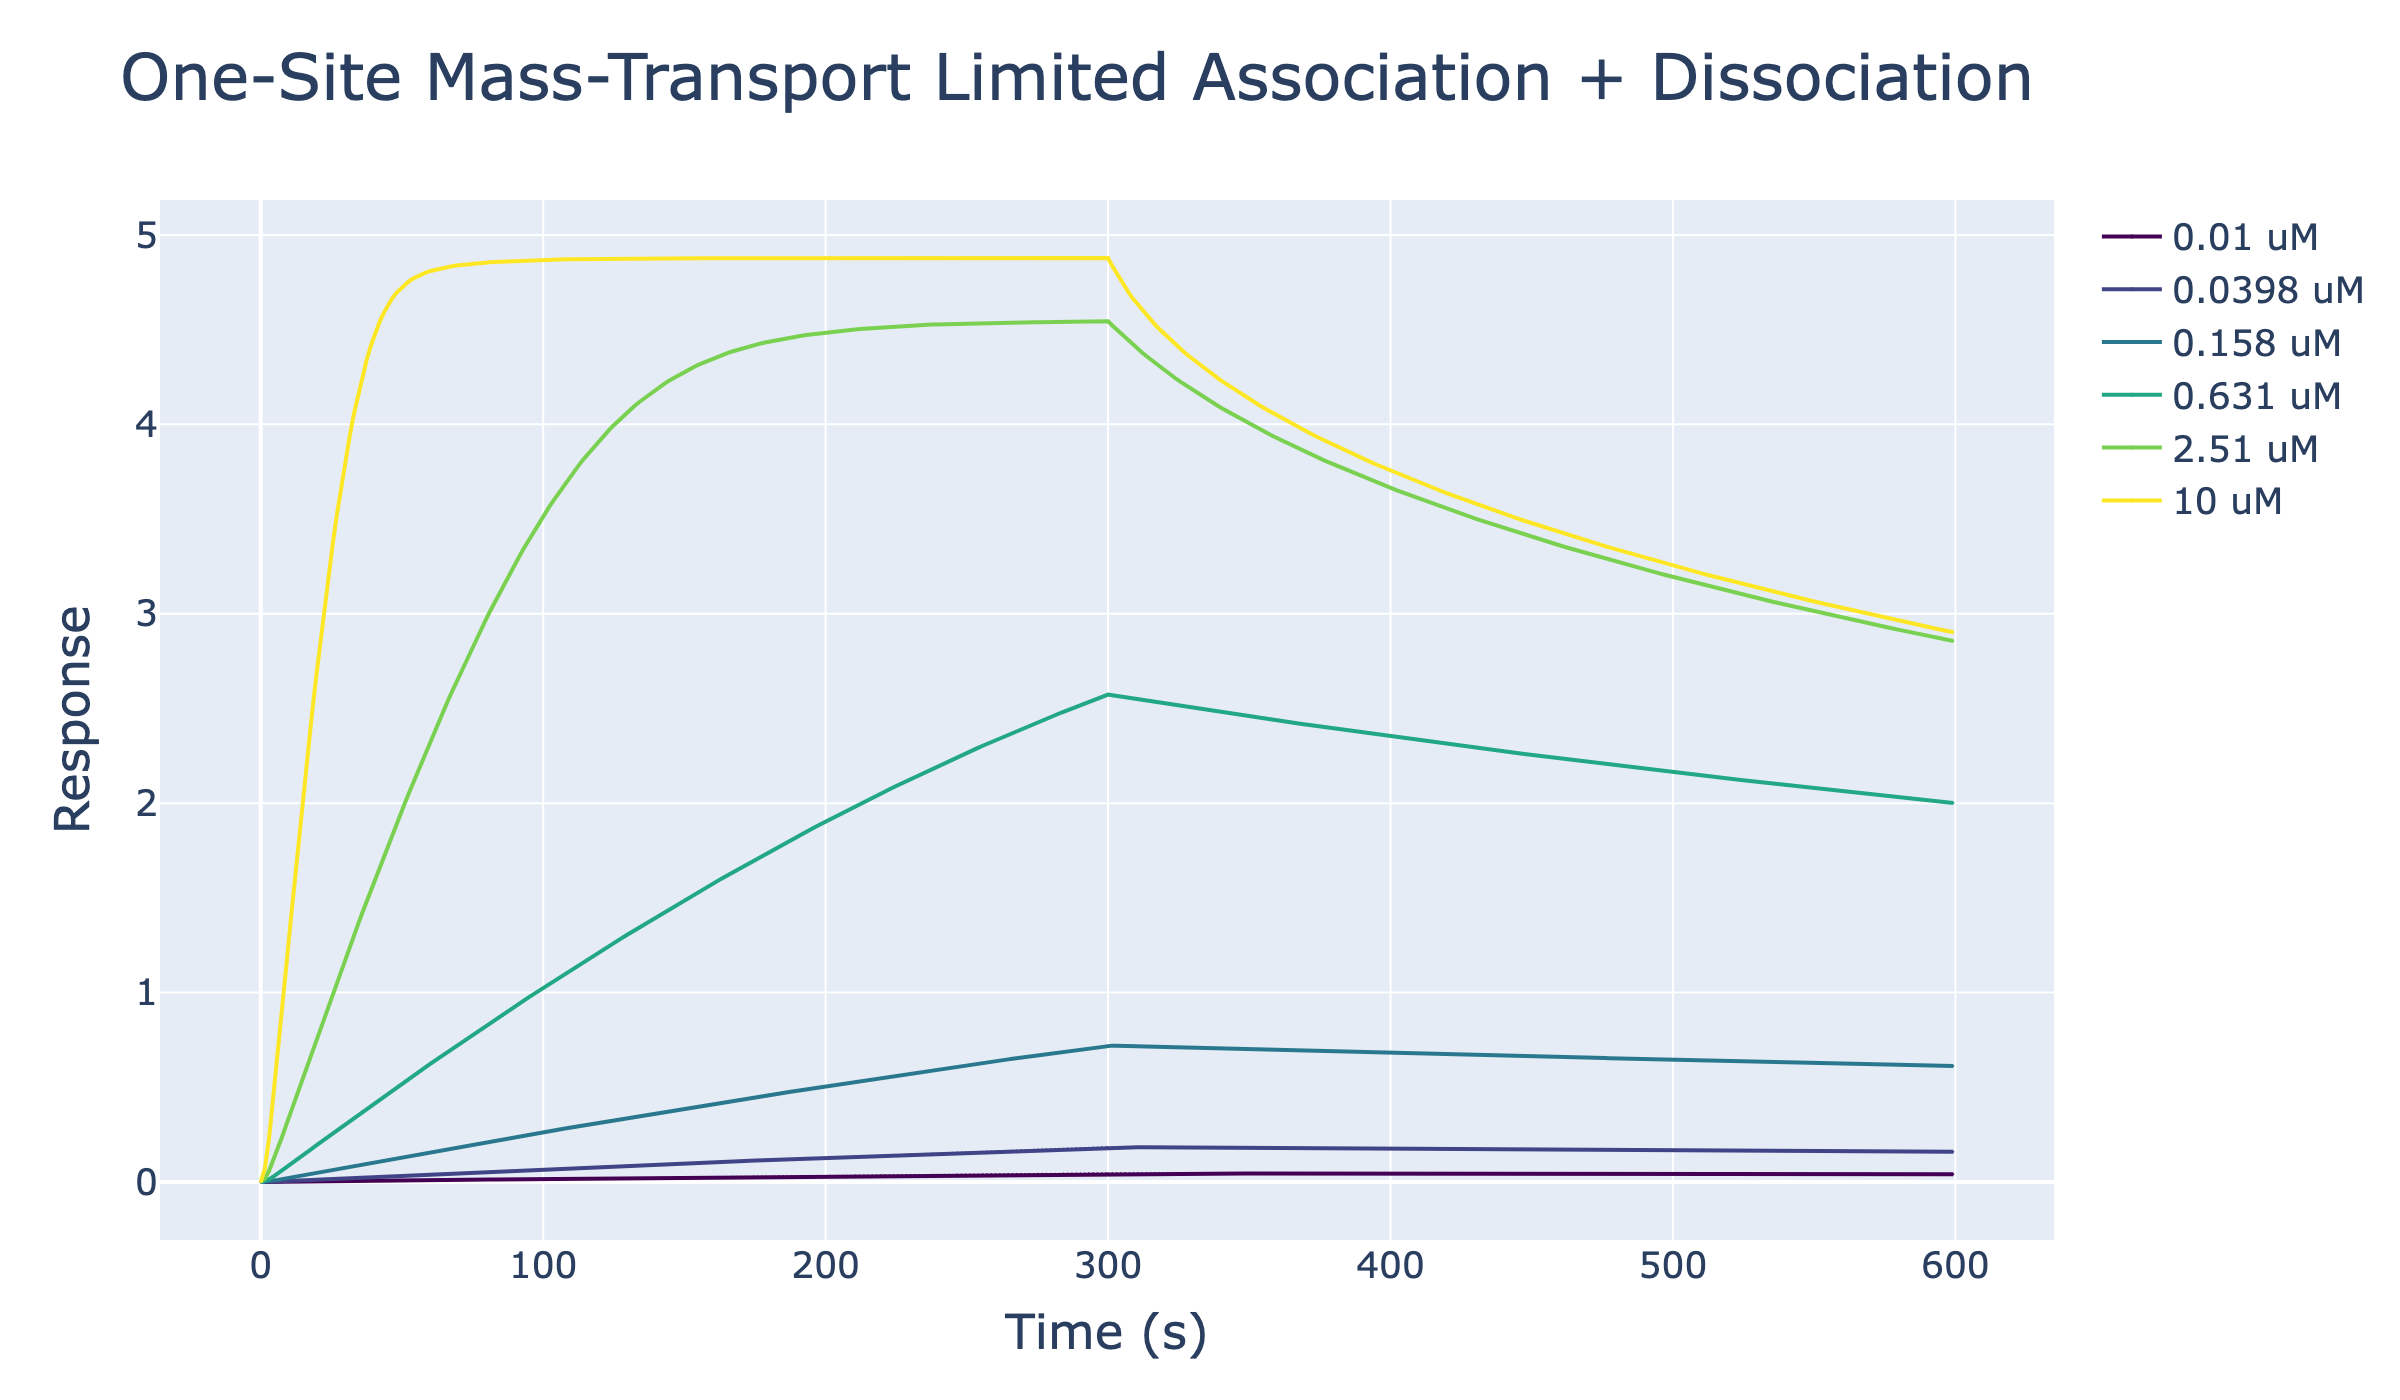

In [8]:
fig = plot_traces(
    xs=combined_xs,
    ys=combined_ys,
    legends=legends,
    colors=colors,
    show=show,
    marker_size=1,
    line_width=2,
)

fig.update_layout(
    title={"text": "One-Site Mass-Transport Limited Association + Dissociation", "font": {"size": 32}},
    xaxis_title="Time (s)",
    yaxis_title="Response",
    font={"size": 20},
    legend={"font": {"size": 18}},
)
fig.update_xaxes(title_font={"size": 24}, tickfont={"size": 18})
fig.update_yaxes(title_font={"size": 24}, tickfont={"size": 18})

show_plotly_static(fig)